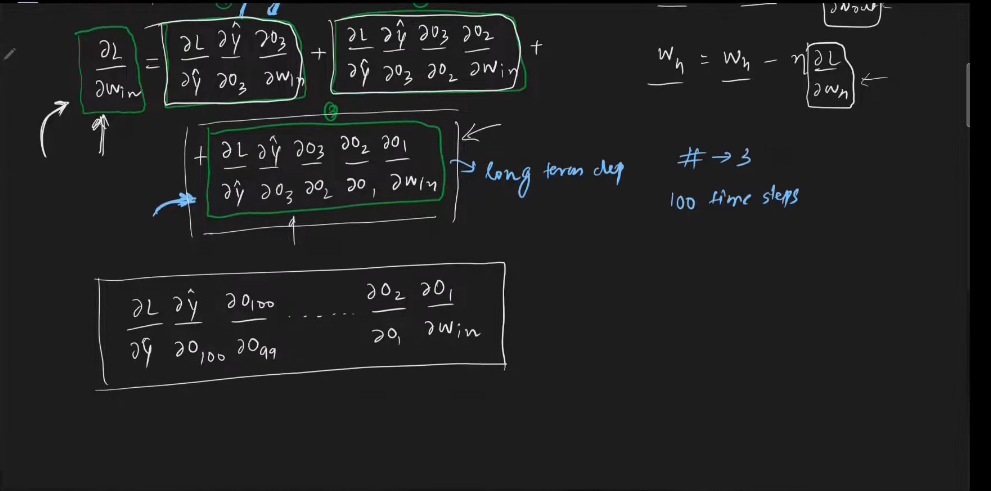

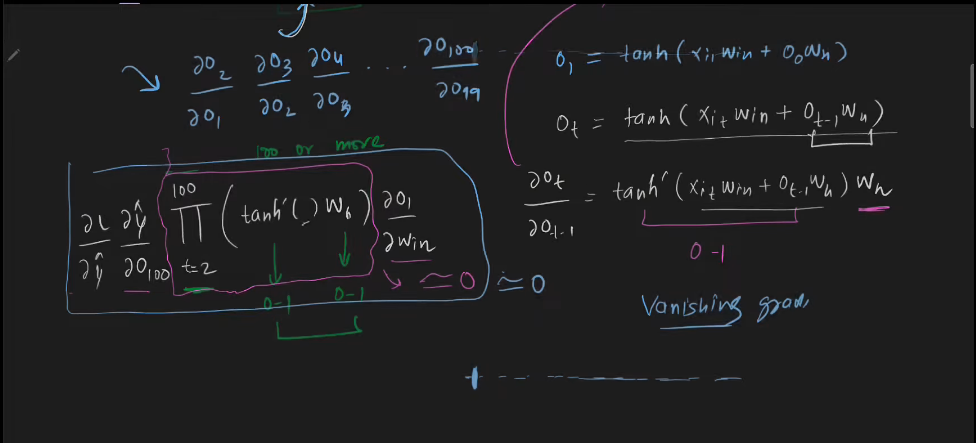

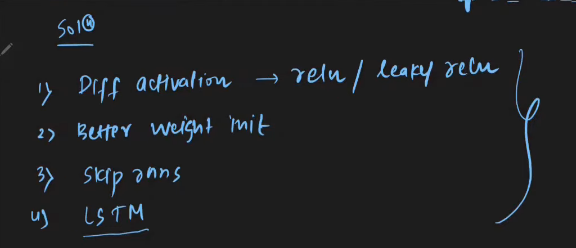



---

## 🎯 Goal: Understand Why RNNs Forget Long-Term Info

You already know:
- RNNs process sequences (like sentences or time series).
- They have a hidden state \( h_t \) that carries memory.
- But when training, **they often fail to learn long-term patterns**.

👉 This is because of the **Vanishing Gradient Problem**.

Let’s break it down using your notes.

---

# 🔍 Step 1: What is Backpropagation Through Time (BPTT)?

In normal neural networks, we update weights using gradients (how much loss changes with weight).

For RNNs, since data comes in sequence, we do **Backpropagation Through Time (BPTT)** — we unroll the network over time.

Imagine this:

```
t=0: x₀ → h₀ → y₀
t=1: x₁ → h₁ → y₁
...
t=100: x₁₀₀ → h₁₀₀ → y₁₀₀
```

To train, we compute gradient of loss \( L \) w.r.t. weights, going backward from \( t=100 \) to \( t=0 \).

---

# 🔢 Step 2: The Gradient Chain (Your First Image)

Look at this equation:

\[
\frac{\partial L}{\partial w_{in}} =
\underbrace{
\frac{\partial L}{\partial \hat{y}} \frac{\partial \hat{y}}{\partial o_3} \frac{\partial o_3}{\partial w_{in}}
}_{\text{short term}}
+
\underbrace{
\frac{\partial L}{\partial \hat{y}} \frac{\partial \hat{y}}{\partial o_3} \frac{\partial o_3}{\partial o_2} \frac{\partial o_2}{\partial w_{in}}
}_{\text{medium term}}
+
\underbrace{
\frac{\partial L}{\partial \hat{y}} \frac{\partial \hat{y}}{\partial o_3} \frac{\partial o_3}{\partial o_2} \frac{\partial o_2}{\partial o_1} \frac{\partial o_1}{\partial w_{in}}
}_{\text{long term dependency}}
\]

This shows how the gradient flows back through time.

- Each term has more derivatives → longer chain.
- The **last term** is what matters for **long-term dependencies**.

Now look at this:

\[
\frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial o_{100}} \cdot \underbrace{
\prod_{t=2}^{100} \left( \tanh'(\cdot) \cdot W_h \right)
}_{\text{this is the problem}} \cdot \frac{\partial o_1}{\partial w_{in}}
\]

This product goes from \( t=2 \) to \( t=100 \) — **99 steps**!

And each term is:
\[
\tanh'(z) \cdot W_h
\]

Where:
- \( \tanh'(z) = 1 - \tanh^2(z) \) → always ≤ 1
- \( W_h \) is usually small (say 0.5 or less)

So each term is **less than 1**.

👉 Multiply 99 numbers <1 → result becomes **almost zero**!

That’s why:
\[
\frac{\partial L}{\partial w_{in}} \approx 0
\]

Even if the input at \( t=1 \) was important, the gradient **vanishes** — no learning happens.

---

# 🧠 Intuition: Why Does This Happen?

Think of it like whispering a message across a room.

> Person 1 whispers: “The cat is on the mat.”  
> Person 2 hears it, repeats…  
> Person 3…  
> …  
> Person 100 says: “...on the...?”

By the end, the message is lost.

Similarly:
- Input at \( t=1 \) affects \( h_1 \), then \( h_2 \), ..., up to \( h_{100} \)
- But each step multiplies by a number <1 → influence shrinks
- After many steps → **no effect**

👉 So the network **can't learn** that "cat" affects "mat" if there are 100 words in between.

---

# ✅ Real Example: Sentence Prediction

Suppose we want to predict:

> "The **dog** ran fast because it was tired."

We need to remember "**dog**" when predicting "**it**".

But if the sentence is:
> "The dog ran fast because it was tired after chasing cats for hours..."

Now "dog" is far from "it".  
RNN may forget "dog" → thinks "it" refers to "cats".

Because the gradient from "dog" to "it" vanishes.

---

# 🔬 Step 3: Math Behind Vanishing Gradient (Your Second Image)

From your notes:

\[
\frac{\partial o_t}{\partial o_{t-1}} = \tanh'(x_t w_{in} + o_{t-1} w_h) \cdot w_h
\]

This is the derivative of output at time \( t \) w.r.t. previous hidden state.

Let’s say:
- \( w_h = 0.5 \)
- \( \tanh'(z) \leq 1 \) → max value is ~1 (when z=0), decreases as |z| increases

So:
\[
\frac{\partial o_t}{\partial o_{t-1}} \leq 0.5
\]

Then:
\[
\frac{\partial o_{100}}{\partial o_1} = \prod_{t=2}^{100} \left( \tanh'(z_t) \cdot w_h \right) \leq (0.5)^{99}
\]

Calculate:
\[
(0.5)^{99} \approx 1.5 \times 10^{-30}
\]

👉 That’s **extremely close to zero**!

So even if \( o_1 \) was very important, its effect on final output is **negligible**.

Hence: **Vanishing Gradient**.

---

# 💡 Solutions (Your Third Image)

You wrote:

1. **Different activation function → ReLU / Leaky ReLU**
2. **Better weight initialization**
3. **Skip connections**
4. **LSTM**

Let’s explain them simply:

### 1️⃣ ReLU vs Tanh

- **Tanh**: Output between -1 and 1 → derivative ≤ 1 → causes vanishing
- **ReLU**: \( f(x) = \max(0,x) \), derivative = 1 for \( x>0 \) → no vanishing!
- But ReLU can cause **dying neurons** (if all inputs negative → always 0)

→ Use **Leaky ReLU**: \( f(x) = \max(0.01x, x) \) → avoids dying

✅ Helps prevent vanishing gradient.

### 2️⃣ Better Weight Initialization

If weights are too small → gradients shrink faster  
If too large → gradients explode

Use **Xavier/Glorot init** or **He init** → balance so gradients don’t vanish/explode.

### 3️⃣ Skip Connections (Residual Networks)

Instead of only \( h_t = f(W h_{t-1}) \), add:
\[
h_t = f(W h_{t-1}) + h_{t-1}
\]

Now gradient can flow directly through the skip path → avoids multiplication chain.

Used in **ResNet**, also helps in RNNs.

### 4️⃣ LSTM (Best Solution)

LSTM adds **gates**:
- **Forget gate**: decides what to keep/delete from memory
- **Input gate**: what new info to store
- **Output gate**: what to output

It has a **cell state** that can **flow unchanged** through time.

👉 So gradient doesn’t have to go through tanh every time — it can pass through directly!

This avoids vanishing gradient.

---

# 🧩 Summary: Vanishing Gradient – Best Understanding

| Concept | Explanation |
|--------|-------------|
| **Problem** | In RNNs, gradients get multiplied many times by numbers <1 → become zero |
| **Cause** | Derivative of tanh is ≤1, and weights are small → product → 0 |
| **Effect** | Network can't learn long-term dependencies |
| **Example** | Can't link "dog" to "it" in a long sentence |
| **Math** | \( \frac{\partial L}{\partial w} \propto \prod_{t=1}^{T} (\tanh' \cdot W) \to 0 \) |
| **Solutions** | ReLU, better init, skip connections, **LSTM** |

---

# 🚀 Final Tip: Think Like This

> An RNN is like a student who writes notes in a notebook.  
> Every day, he updates his notes based on yesterday’s notes.  
> But if he copies poorly (small weights), or uses a fading pen (tanh), the earlier notes **fade away**.  
> Only recent stuff matters.  
> → That’s vanishing gradient.

But with **LSTM**, he uses a **highlighter** and **bookmark** — keeps important things alive.

---



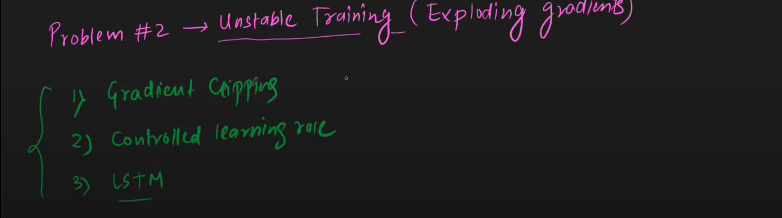



> 🟣 Problem #2 → Unstable Training (Exploding gradients)  
> 🔹 1) Gradient Clipping  
> 🔹 2) Controlled learning rate  
> 🔹 3) LSTM

---

## 🧨 What is Exploding Gradient?

While **vanishing gradient** makes gradients *too small* (so no learning),  
**exploding gradient** makes them *too large* — like a snowball rolling downhill, growing uncontrollably.

👉 This causes the weights to become huge → training becomes unstable → model diverges or crashes.

---

### 🔍 How Does It Happen? (Intuition + Math)

Let’s go back to RNNs.

Recall the recurrence:
\[
h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)
\]

But when we compute gradients during **Backpropagation Through Time (BPTT)**, we get this chain:

\[
\frac{\partial L}{\partial w_h} \propto \sum_{t=1}^{T} \left( \prod_{k=t}^{T} \frac{\partial o_k}{\partial o_{k-1}} \right) \cdot \frac{\partial o_t}{\partial w_h}
\]

And:
\[
\frac{\partial o_t}{\partial o_{t-1}} = \tanh'(z_t) \cdot w_h
\]

Now here’s the twist:

- If \( |w_h| > 1 \), then even if \( \tanh'(z_t) < 1 \), the product might still grow!
- For example: \( w_h = 2 \), \( \tanh'(z_t) \approx 0.8 \) → \( 0.8 \times 2 = 1.6 > 1 \)
- So each step multiplies by something **greater than 1**

After many steps:
\[
(1.6)^{100} \approx 10^{17} \quad \text{→ Huge number!}
\]

This means:
> The gradient grows exponentially → blows up → weights become infinite → **training explodes**!

---

### 🎯 Real Example: Why This Matters

Imagine you're training an RNN to predict stock prices over 100 days.

If the network learns that “a sudden drop yesterday” affects today’s price, but the weight is too big, the gradient could explode.

Result:
- Weights go from `0.5` → `10` → `1000` → `∞`
- Model starts making wild predictions
- Training fails

It’s like trying to balance a pencil on your finger — if you move too fast, it falls.

---

### 💡 Intuition: The "Snowball Effect"

Think of gradient flow like a **snowball rolling down a hill**:

- If the slope is gentle → snowball stays small → stable
- If the slope is steep → snowball gets bigger and bigger → crashes everything

In RNNs:
- The "slope" is controlled by \( w_h \)
- If \( |w_h| > 1 \), gradient keeps growing → **explosion**
- If \( |w_h| < 1 \), gradient shrinks → **vanishing**
- Only when \( |w_h| \approx 1 \), gradient stays stable

But in practice, weights are randomly initialized → can be large → risk of explosion.

---

## ✅ Solutions to Exploding Gradients

Let’s go through the three solutions from your notes:

---

### 🔹 1) Gradient Clipping

#### 📌 Idea: Cut off gradients that are too big

Just like cutting a rope before it breaks.

#### 🔧 How?
Before updating weights, check if gradient norm is too large.

If \( \| \nabla w \| > \text{threshold} \) (e.g., 1 or 5), then:
\[
\nabla w \leftarrow \frac{\nabla w}{\| \nabla w \|} \times \text{threshold}
\]

👉 This **rescales** the gradient to prevent explosion.

#### 🎯 Analogy:
You’re lifting weights. If the barbell is too heavy, you don’t lift it fully — you reduce it to a safe amount.

✅ Pros: Simple, effective, widely used  
❌ Cons: Doesn't fix root cause — just stops the explosion

---

### 🔹 2) Controlled Learning Rate

#### 📌 Idea: Use smaller learning rates

Learning rate (\( \eta \)) controls how much we update weights.

If gradient is huge, even small \( \eta \) helps.

But better: **Adaptive learning rates** like Adam, RMSProp — they automatically adjust based on gradient size.

#### 🎯 Analogy:
Driving a car. If the road is bumpy (high gradient), drive slowly (small learning rate). If smooth, go faster.

✅ Helps stabilize training  
⚠️ But doesn't solve the root issue — exploding gradients still happen

---

### 🔹 3) LSTM (Long Short-Term Memory)

#### 📌 Best Solution: Prevent explosion at the source

LSTM adds **gates** that control information flow.

Key idea: **Cell state** can carry information unchanged through time.

Structure:
- **Forget gate**: decides what to forget
- **Input gate**: decides what to store
- **Output gate**: decides what to output

And most importantly:
\[
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
\]
Where:
- \( f_t \in [0,1] \): forget gate (sigmoid)
- \( i_t \in [0,1] \): input gate
- \( \tilde{C}_t \): new memory

So the cell state \( C_t \) can:
- Keep old info (if \( f_t \approx 1 \))
- Add new info (if \( i_t \approx 1 \))

👉 **No tanh activation on the main path** → no vanishing/exploding due to activation!

Gradient can flow **directly** through the cell state without passing through sigmoid/tanh every time.

#### 🎯 Analogy:
Instead of copying notes daily (which fades), use a **digital backup** that saves everything exactly — no loss or blow-up.

✅ LSTM solves both vanishing AND exploding gradients  
✅ Used in almost all modern sequence models

---

## 🔄 Summary Table: Vanishing vs Exploding

| Issue | Cause | Gradient Behavior | Fix |
|------|-------|-------------------|-----|
| **Vanishing Gradient** | \( |w_h| < 1 \), tanh derivative <1 | Gradient → 0 | ReLU, LSTM, better init |
| **Exploding Gradient** | \( |w_h| > 1 \), gradient grows | Gradient → ∞ | Gradient clipping, LSTM |

---

## 🚀 Final Intuition: Think of RNNs Like a River

Imagine a river flowing through a canyon:

- **Vanishing gradient**: Water evaporates as it flows → weak stream at end
- **Exploding gradient**: Water picks up speed and rocks → flood → destroys everything
- **LSTM**: A canal with locks → water flows smoothly, no overflow, no drying

RNNs are like rivers with no control.  
LSTM is like a smart irrigation system.

---

## ✅ Key Takeaways

1. **Exploding gradients** happen when weights are too large → gradients grow exponentially.
2. **Gradient clipping** cuts off large gradients → prevents crash.
3. **Small learning rate** helps but isn't enough.
4. **LSTM** is the best solution — it uses gates to control flow → avoids both vanishing and exploding.

---




---

### **RNN Interview Q&A (Minimalist, Technical, Interview-Ready)**

---

#### **Q1: What is an RNN? Why is it used for sequences?**

**A:**  
An RNN (Recurrent Neural Network) processes sequential data by maintaining a hidden state \( h_t \) that captures information from past inputs. At each time step \( t \), it computes:

\[
h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)
\]

This recurrence allows the network to model temporal dependencies, making it suitable for tasks like language modeling, speech recognition, and time series prediction.

---

#### **Q2: What is Backpropagation Through Time (BPTT)?**

**A:**  
BPTT is the application of backpropagation to RNNs. The network is "unrolled" across time steps, and gradients of the loss with respect to parameters are computed by applying the chain rule through the computational graph over time.

It enables learning of recurrent weights by propagating errors backward from output to earlier time steps.

---

#### **Q3: What is the vanishing gradient problem in RNNs?**

**A:**  
The vanishing gradient problem occurs when gradients of the loss with respect to early time steps become extremely small due to repeated multiplication of values less than 1 (e.g., derivatives of \( \tanh \) and small weights).

As a result, the network fails to learn long-range dependencies because early inputs have negligible impact on the final loss.

---

#### **Q4: What is the exploding gradient problem?**

**A:**  
The exploding gradient problem occurs when the recurrent weight matrix \( W_{hh} \) has eigenvalues greater than 1, causing gradients to grow exponentially during BPTT.

This leads to unstable training, large parameter updates, and numerical overflow (NaNs).

---

#### **Q5: Why do vanishing and exploding gradients happen in RNNs?**

**A:**  
Both stem from the structure of BPTT. The gradient at time \( t \) with respect to an earlier state involves a product of Jacobians:

\[
\frac{\partial h_t}{\partial h_1} = \prod_{k=2}^t \frac{\partial h_k}{\partial h_{k-1}} = \prod_{k=2}^t W_{hh}^\top \cdot \text{diag}(1 - h_k^2)
\]

- If \( \|W_{hh}\| < 1 \) → product decays → **vanishing**  
- If \( \|W_{hh}\| > 1 \) → product grows → **exploding**

This multiplicative nature over long sequences causes instability.

---

#### **Q6: How do you fix exploding gradients?**

**A:**  
Common fixes:
- **Gradient clipping**: Rescale gradients if their norm exceeds a threshold.
- **Adaptive optimizers**: Use RMSProp or Adam to scale learning rates.
- **Proper initialization**: Initialize \( W_{hh} \) to have spectral norm near 1.

Note: These stabilize training but do not solve long-term dependency issues.

---

#### **Q7: How do you fix vanishing gradients?**

**A:**  
Solutions include:
- **LSTM/GRU**: Use gated architectures that allow constant error flow.
- **ReLU or Leaky ReLU**: Avoid saturating activations (less common in RNNs).
- **Skip connections**: Enable direct gradient paths.
- **Weight initialization**: Use orthogonal initialization for \( W_{hh} \).

LSTM is the most effective solution.

---

#### **Q8: Why does LSTM solve the vanishing gradient problem?**

**A:**  
LSTM introduces a cell state \( c_t \) with additive updates:

\[
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
\]

The forget gate \( f_t \) controls retention. When \( f_t \approx 1 \), the gradient flows through \( c_t \) with minimal transformation — no repeated matrix multiplication or activation derivatives.

This **constant error carousel** allows gradients to propagate unchanged over long sequences, preventing vanishing.

---

#### **Q9: What are the limitations of RNNs despite using LSTM?**

**A:**  
Even with LSTM:
- Training is sequential → hard to parallelize.
- Still slower than Transformer-based models.
- Can struggle with very long sequences (>1000 steps).
- More complex than feedforward models.

Hence, Transformers have largely replaced RNNs in NLP.

---

#### **Q10: When would you still use an RNN?**

**A:**  
RNNs (especially LSTM/GRU) are still used when:
- Sequence lengths are moderate.
- Memory efficiency is important.
- Real-time streaming prediction is needed (online inference).
- Model interpretability matters (e.g., medical time series).

They remain relevant in embedded systems and time series applications.

---

